## First stage: Claim Extractor

This first stage is already done by the LLM's pipeline, we will have to evaluate the outputs of the models Qwen3-1.7b (RAG) and Qwen3-4b (LoRA and RAG)
the output is the the folder Knowledge graph, in this case on the folder doc_146120936:
- LoRA-Output-4B_doc_146120936.json (Qwen3-4b)
- RAG-Output-4B_doc_146120936.json (Qwen3-4b)
- RAG-Output_doc_146120936.json (Qwen3-1.7b)

## Second stage: Checker
The files mentioned above will be checked if they either are:
- Supported by the gold standard answer;
- Contradicted by the gold standard answer;
- Not verifiable by the gold standard answer.

In [11]:
import glob

import json

import os
from huggingface_hub import InferenceClient
from groq import Groq
import time

from tqdm import tqdm

import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict

In [12]:
GROQ_KEY = os.getenv("GROQ_API_KEY")
FILES = glob.glob("./results/clean_*-Output*.json")
gold_qa = "./Knowledge-graph/doc_146120936/Gold-QA_146120936.json"


In [4]:


random.seed(42)

with open(gold_qa, "r", encoding="utf-8") as f:
    gold_data = json.load(f)
    gold_dict = {item["question"]: item.get("triplets") for item in gold_data["pairs"]}

total_questions = 0
for file in FILES:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
        total_questions += len(data["results"])

print(f"Total questions to process: {total_questions}")

Answers = []
num_questions = 0

progress = tqdm(total=total_questions, desc="Global Progress", unit="q")

client = Groq(api_key=GROQ_KEY)

for file in FILES:
    print("Processing file:", file)

    os.makedirs("results", exist_ok=True)

    output_file = os.path.join("results", f"evaluated_{os.path.basename(file)}")

    results = {"results": []}

    with open(file, "r", encoding="utf-8") as f:

        data = json.load(f)
        for item in data["results"]:
            question = item["question"]

            num_questions += 1

            t = item["triplets"]

            if isinstance(t, dict) and "triplets" in t:
                triplets = t["triplets"]
            elif isinstance(t, list):
                triplets = t
            else:
                triplets = []

            gold_answer = gold_dict.get(question, None)

            prompt = f"""
You are verifying whether extracted knowledge triplets correctly answer a scientific question.

You have:
- <QUESTION>
- <TRIPLETS>
- <GOLD_STANDARD_ANSWER>

Return ONLY:
0 - supported
1 - contradicted
2 - not verifiable

<QUESTION>
{question}
</QUESTION>

<TRIPLETS>
{triplets}
</TRIPLETS>

<GOLD_STANDARD_ANSWER>
{gold_answer}
</GOLD_STANDARD_ANSWER>

Answer only with a single number: 0, 1, or 2.
"""

            completion = client.chat.completions.create(
                model="groq/compound",
                messages=[
                    {
                        "role": "user",
                        "content": prompt
                    }
                ]
            )
            result = completion.choices[0].message.content

            output_row = {
                "question": question,
                "triplets": triplets,
                "gold_answer": gold_answer,
                "result": result,
            }
            
            results["results"].append(output_row)

            with open(output_file, "w", encoding="utf-8") as f_out:
                json.dump(results, f_out, indent=4, ensure_ascii=False)

            print(f"\nSaved output to: {output_file}\n")

            progress.update(1)

            time.sleep(5)
            
    
print("Total questions processed:", num_questions)

Total questions to process: 98


Global Progress:   0%|          | 0/98 [00:00<?, ?q/s]

Processing file: ./results\clean_Base-Output-4B_doc_146120936.json


Global Progress:   1%|          | 1/98 [00:01<01:37,  1.01s/q]


Saved output to: results\evaluated_clean_Base-Output-4B_doc_146120936.json



...


Saved output to: results\evaluated_clean_Base-Output_doc_146120936.json



Global Progress:  99%|█████████▉| 97/98 [12:14<00:06,  6.89s/q]


Saved output to: results\evaluated_clean_Base-Output_doc_146120936.json



Global Progress: 100%|██████████| 98/98 [12:21<00:00,  7.08s/q]


Saved output to: results\evaluated_clean_Base-Output_doc_146120936.json

Total questions processed: 98


## Final stage: Aggregator
This final will assess how the knowledge injection methods helped with hallucination rate

The Aggregator consolidates the verification results into interpretable evaluation metrics. This module computes:
- the percentage of correct (supported) triplets,
- the percentage of hallucinated triplets (contradicted + not verifiable),
- the absolute number of hallucinations per response.

In [13]:
def aggregate_metrics(evaluated_file):
    with open(evaluated_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    supported = 0
    contradicted = 0
    unverifiable = 0

    hallucinations_per_response = []

    for item in data["results"]:
        result = str(item["result"]).strip()
        
        if result == "0":
            supported += 1
        elif result == "1":
            contradicted += 1
        elif result == "2":
            unverifiable += 1
        
        # hallucination = contradicted or not verifiable
        if result in ["1", "2"]:
            hallucinations_per_response.append(item["question"])
    
    total = supported + contradicted + unverifiable
    
    metrics = {
        "total_triplets": total,
        "supported": supported,
        "contradicted": contradicted,
        "not_verifiable": unverifiable,
        
        "supported_percent": round(100 * supported / total, 2),
        "hallucinated_percent": round(100 * (contradicted + unverifiable) / total, 2),
        
        "hallucinations_count": contradicted + unverifiable,
        "hallucinations_per_response": hallucinations_per_response,
    }

    return metrics


In [16]:
EVA_FILES = glob.glob("./results/evaluated*")

all_metrics = []
file_names = []
def get_display_name(file_path):
    filename = os.path.basename(file_path)
    
    if "LoRA-4B" in filename or "LoRA-Output-4B" in filename:
        return "LoRA-4B"
    elif "RAG-4B" in filename or "RAG-Output-4B" in filename:
        return "RAG-4B"
    elif "RAG-1.7B" in filename or ("RAG-Output" in filename and "4B" not in filename):
        return "RAG-1.7B"
    elif "Base-Output-4B" in filename:
        return "Base-4B"
    elif "Base-Output" in filename and "4B" not in filename:
        return "Base-1.7B"
    elif "Base" in filename:
        return "Base-1.7B"   # fallback for plain "Base"
    

def categorize_model(model_name):
    if "Base" in model_name:
        return "Base"
    elif "LoRA" in model_name:
        return "LoRA"
    elif "RAG" in model_name:
        return "RAG"
    else:
        return "Other"

for file in EVA_FILES:
    print(f"Hallucination metrics for the file: {os.path.basename(file)}")
    metrics = aggregate_metrics(file)
    
    display_name = get_display_name(file)
    
    metrics['file_name'] = display_name
    metrics['model_type'] = categorize_model(display_name)
    metrics['model_size'] = "4B" if "4B" in display_name else "1.7B"
    metrics['ki_method'] = "KI" if "Base" not in display_name else "No-KI"
    
    all_metrics.append(metrics)
    file_names.append(display_name)
    print(json.dumps(metrics, indent=4))
    print("-" * 50)



Hallucination metrics for the file: evaluated_clean_Base-Output-4B_doc_146120936.json
{
    "total_triplets": 49,
    "supported": 2,
    "contradicted": 2,
    "not_verifiable": 45,
    "supported_percent": 4.08,
    "hallucinated_percent": 95.92,
    "hallucinations_count": 47,
    "hallucinations_per_response": [
        "What is a subtask of dense prediction tasks?",
        "What is another name for Content-Aware ReAssembly of FEatures?",
        "What method is used for Feature Pyramid Network?",
        "What method is used for U-Net?",
        "What method is used for instance segmentation?",
        "What task is used for dense prediction tasks?",
        "Which method is part of Faster RCNN?",
        "Which method is compared with Global&Local?",
        "Which dataset is used to evaluate Faster RCNN?",
        "Which dataset is used to evaluate Global&Local?",
        "Which dataset benchmarks image inpainting?",
        "What is another name for guided upsampling?",
      

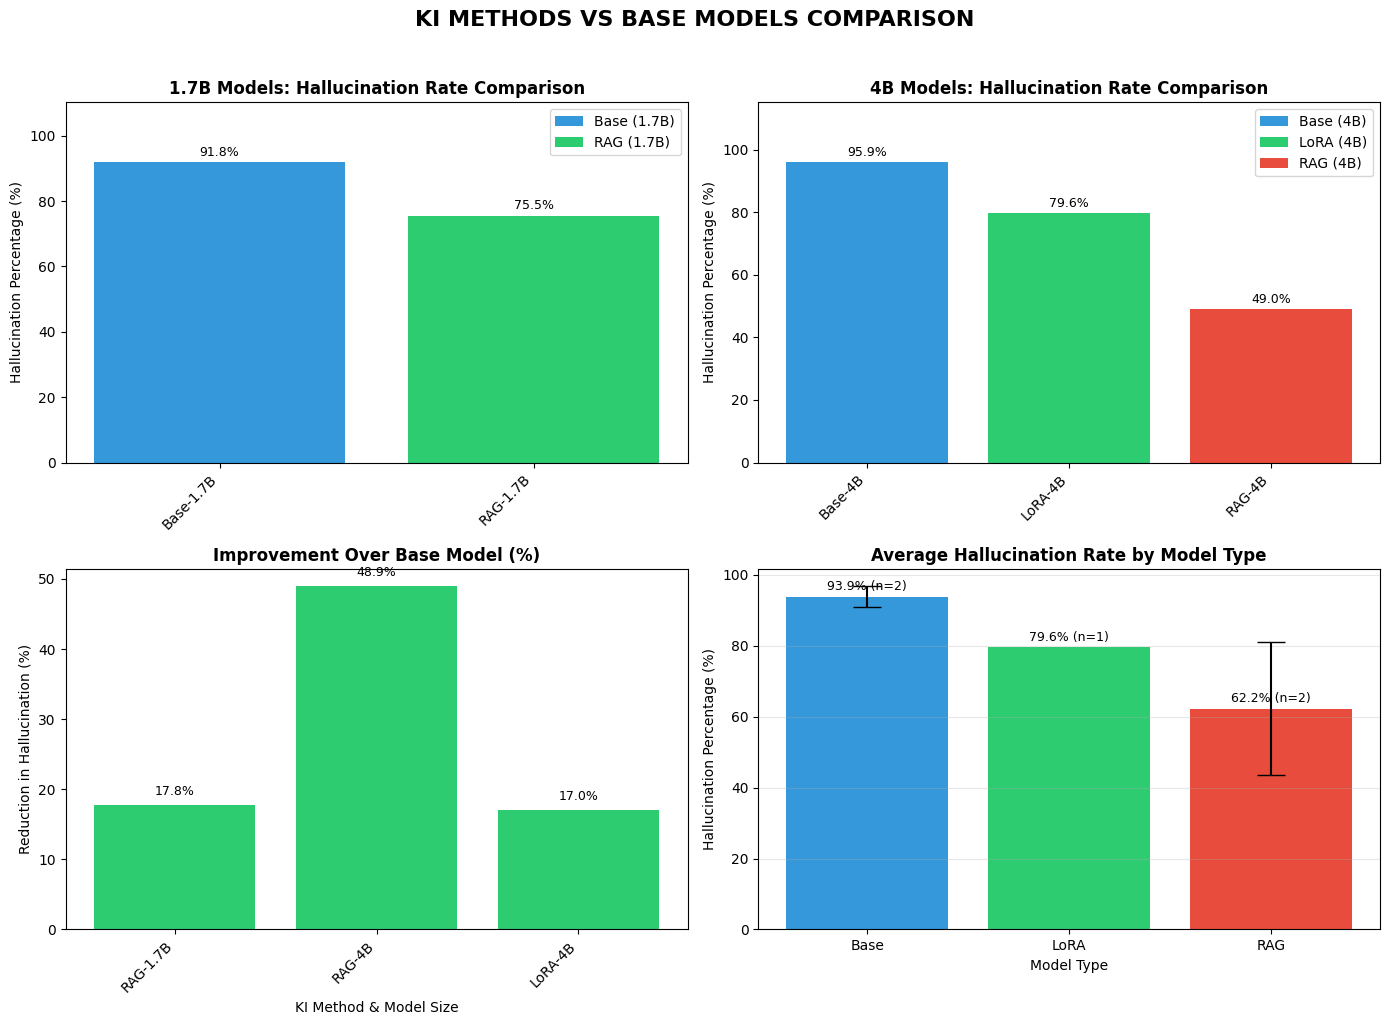

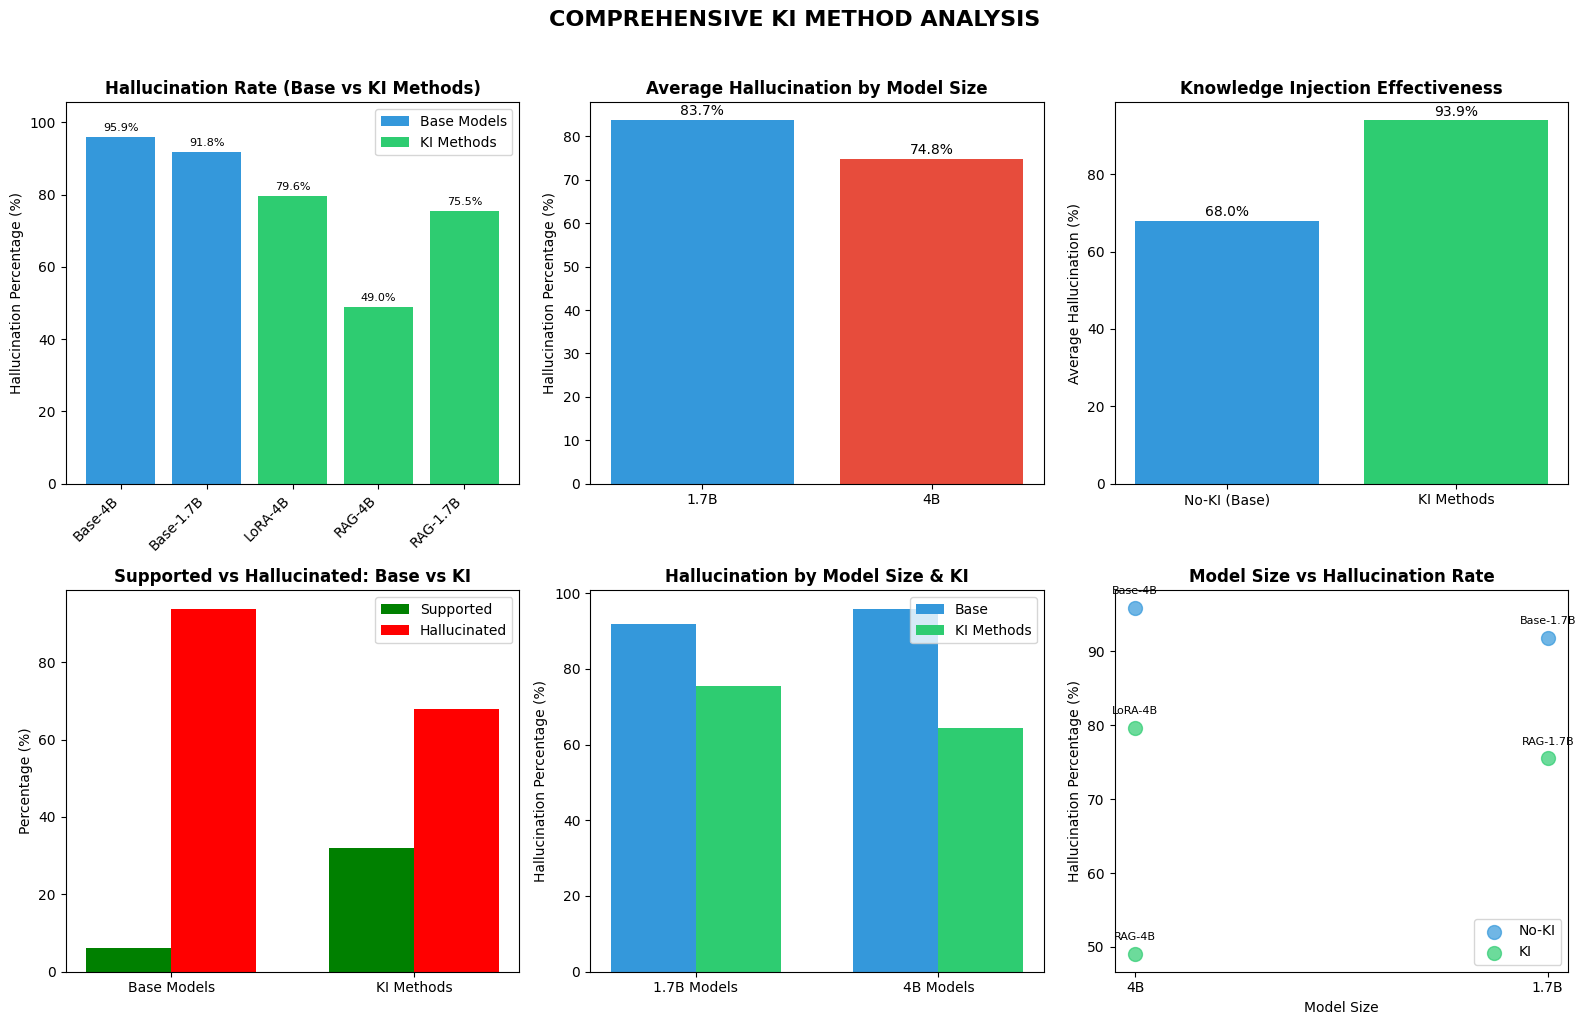

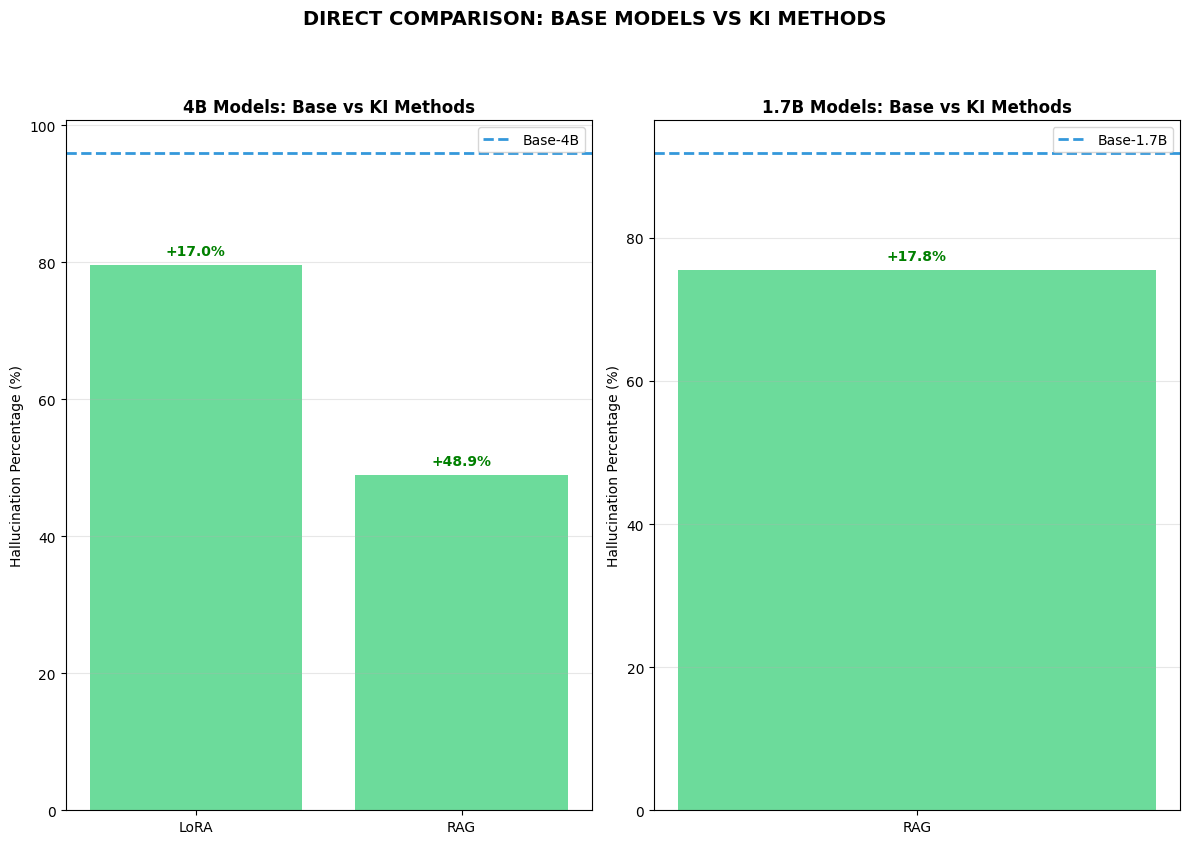

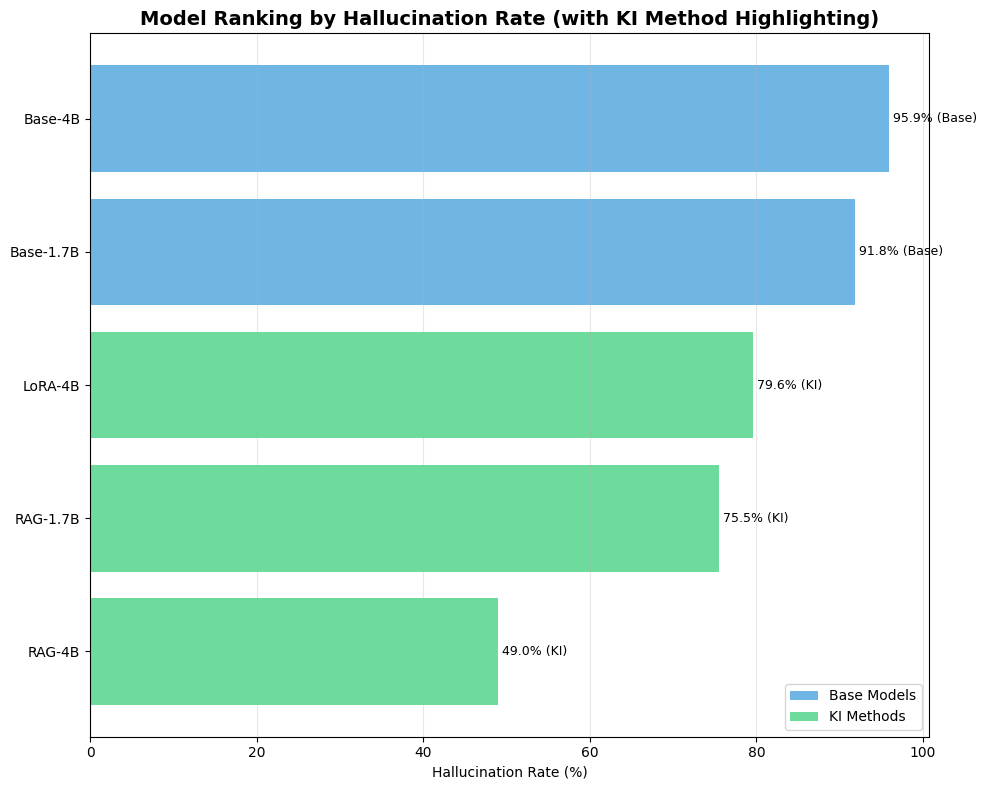


ENHANCED STATISTICAL ANALYSIS: BASE VS KI METHODS

Total files analyzed: 5
Base models: 2
KI methods: 3
Total triplets analyzed: 245

OVERALL PERFORMANCE
Mean hallucination rate (All models): 78.37%
Mean hallucination rate (Base only): 93.88%
Mean hallucination rate (KI only): 68.03%
Average improvement with KI: 27.54%

BY MODEL SIZE

1.7B Models:
  Base average: 91.84%
  KI average: 75.51%
  Improvement: +17.78%

4B Models:
  Base average: 95.92%
  KI average: 64.28%
  Improvement: +32.98%

BY KI METHOD

RAG:
  RAG-4B: 48.98%
  RAG-1.7B: 75.51%

LoRA:
  LoRA-4B: 79.59%

BEST AND WORST PERFORMERS
Best performer: RAG-4B (48.98%)
Worst performer: Base-4B (95.92%)

Best KI method: RAG-4B
Best Base model: Base-1.7B

Enhanced data saved to 'plots/enhanced_ki_analysis_summary.csv'

All plots saved in 'plots/' directory:
  - ki_vs_base_comparison.png
  - comprehensive_ki_analysis.png
  - direct_comparison_base_vs_ki.png
  - ranking_with_ki_highlight.png


In [18]:
df = pd.DataFrame(all_metrics)

# Create plots directory if it doesn't exist
plots_dir = "plots"
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)
    print(f"Created directory: {plots_dir}")

# ============ NEW: GROUPED COMPARISON PLOTS ============

# 1. GROUPED COMPARISON: Base vs KI Methods by Model Size
plt.figure(figsize=(14, 10))

# Subplot 1: 1.7B Models Comparison
plt.subplot(2, 2, 1)
df_17b = df[df['model_size'] == '1.7B'].sort_values('model_type')
colors = ['#3498db', '#2ecc71', '#e74c3c']  # Base, RAG, LoRA

# Filter only existing model types
existing_types = df_17b['model_type'].unique()
color_map = {typ: colors[i] for i, typ in enumerate(existing_types)}

bars = plt.bar(df_17b['file_name'], df_17b['hallucinated_percent'], 
               color=[color_map[t] for t in df_17b['model_type']])
plt.title('1.7B Models: Hallucination Rate Comparison', fontsize=12, fontweight='bold')
plt.ylabel('Hallucination Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(df_17b['hallucinated_percent']) * 1.2)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Create custom legend
legend_elements = [plt.Rectangle((0,0),1,1,facecolor=color_map[t], label=f'{t} (1.7B)') 
                   for t in existing_types]
plt.legend(handles=legend_elements, loc='upper right')

# Subplot 2: 4B Models Comparison
plt.subplot(2, 2, 2)
df_4b = df[df['model_size'] == '4B'].sort_values('model_type')
colors = ['#3498db', '#2ecc71', '#e74c3c']  # Base, RAG, LoRA

existing_types_4b = df_4b['model_type'].unique()
color_map_4b = {typ: colors[i] for i, typ in enumerate(existing_types_4b)}

bars = plt.bar(df_4b['file_name'], df_4b['hallucinated_percent'], 
               color=[color_map_4b[t] for t in df_4b['model_type']])
plt.title('4B Models: Hallucination Rate Comparison', fontsize=12, fontweight='bold')
plt.ylabel('Hallucination Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(df_4b['hallucinated_percent']) * 1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

legend_elements_4b = [plt.Rectangle((0,0),1,1,facecolor=color_map_4b[t], label=f'{t} (4B)') 
                      for t in existing_types_4b]
plt.legend(handles=legend_elements_4b, loc='upper right')

# Subplot 3: Performance Improvement Comparison
plt.subplot(2, 2, 3)
# Calculate improvement over base for each model size
improvement_data = []
labels = []

for size in ['1.7B', '4B']:
    size_df = df[df['model_size'] == size]
    base_value = size_df[size_df['model_type'] == 'Base']['hallucinated_percent'].values
    if len(base_value) > 0:
        base_value = base_value[0]
        
        for model_type in ['RAG', 'LoRA']:
            ki_value = size_df[size_df['model_type'] == model_type]['hallucinated_percent'].values
            if len(ki_value) > 0:
                ki_value = ki_value[0]
                improvement = ((base_value - ki_value) / base_value) * 100
                improvement_data.append(improvement)
                labels.append(f'{model_type}-{size}')

if improvement_data:
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in improvement_data]
    bars = plt.bar(range(len(improvement_data)), improvement_data, color=colors)
    plt.title('Improvement Over Base Model (%)', fontsize=12, fontweight='bold')
    plt.ylabel('Reduction in Hallucination (%)')
    plt.xlabel('KI Method & Model Size')
    plt.xticks(range(len(improvement_data)), labels, rotation=45, ha='right')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    for bar, imp in zip(bars, improvement_data):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., 
                 height + (1 if height >= 0 else -3),
                 f'{imp:.1f}%', ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)

# Subplot 4: Grouped by KI Method
plt.subplot(2, 2, 4)
# Group data by model type and calculate averages
grouped = df.groupby('model_type')['hallucinated_percent'].agg(['mean', 'std', 'count']).reset_index()
x_pos = np.arange(len(grouped))

bars = plt.bar(x_pos, grouped['mean'], yerr=grouped['std'], capsize=10, 
               color=['#3498db', '#2ecc71', '#e74c3c'][:len(grouped)])
plt.title('Average Hallucination Rate by Model Type', fontsize=12, fontweight='bold')
plt.ylabel('Hallucination Percentage (%)')
plt.xlabel('Model Type')
plt.xticks(x_pos, grouped['model_type'])
plt.grid(axis='y', alpha=0.3)

for i, (mean_val, count_val) in enumerate(zip(grouped['mean'], grouped['count'])):
    plt.text(i, mean_val + 1, f'{mean_val:.1f}% (n={count_val})', 
             ha='center', va='bottom', fontsize=9)

plt.suptitle('KI METHODS VS BASE MODELS COMPARISON', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'ki_vs_base_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# ============ ENHANCED OVERVIEW PLOT (with KI grouping) ============

plt.figure(figsize=(16, 10))

# Subplot 1: Hallucination rate by file with KI highlighting
plt.subplot(2, 3, 1)
# Create color coding: Blue for Base, Green for KI methods
colors = ['#3498db' if 'Base' in name else '#2ecc71' for name in file_names]
bars = plt.bar(file_names, df['hallucinated_percent'], color=colors)
plt.title('Hallucination Rate (Base vs KI Methods)', fontsize=12, fontweight='bold')
plt.ylabel('Hallucination Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(df['hallucinated_percent']) * 1.1)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Base Models'),
                   Patch(facecolor='#2ecc71', label='KI Methods')]
plt.legend(handles=legend_elements, loc='upper right')

# Subplot 2: Comparison by Model Size
plt.subplot(2, 3, 2)
size_groups = df.groupby('model_size')['hallucinated_percent'].mean()
colors = ['#3498db', '#e74c3c']
bars = plt.bar(size_groups.index, size_groups.values, color=colors)
plt.title('Average Hallucination by Model Size', fontsize=12, fontweight='bold')
plt.ylabel('Hallucination Percentage (%)')

for bar, val in zip(bars, size_groups.values):
    plt.text(bar.get_x() + bar.get_width()/2., val + 0.5,
             f'{val:.1f}%', ha='center', va='bottom')

# Subplot 3: KI Effectiveness
plt.subplot(2, 3, 3)
ki_effectiveness = df.groupby('ki_method')['hallucinated_percent'].mean()
colors = ['#3498db', '#2ecc71']
bars = plt.bar(['No-KI (Base)', 'KI Methods'], ki_effectiveness.values, color=colors)
plt.title('Knowledge Injection Effectiveness', fontsize=12, fontweight='bold')
plt.ylabel('Average Hallucination (%)')

for bar, val in zip(bars, ki_effectiveness.values):
    plt.text(bar.get_x() + bar.get_width()/2., val + 0.5,
             f'{val:.1f}%', ha='center', va='bottom')

# Subplot 4-6: Distribution plots for Base vs KI
plt.subplot(2, 3, 4)
base_df = df[df['ki_method'] == 'No-KI']
ki_df = df[df['ki_method'] == 'KI']

x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [base_df['supported_percent'].mean(), ki_df['supported_percent'].mean()], 
        width, label='Supported', color='green')
plt.bar(x + width/2, [base_df['hallucinated_percent'].mean(), ki_df['hallucinated_percent'].mean()], 
        width, label='Hallucinated', color='red')

plt.title('Supported vs Hallucinated: Base vs KI', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xticks(x, ['Base Models', 'KI Methods'])
plt.legend()

# Subplot 5: Model size comparison within each category
plt.subplot(2, 3, 5)
base_17b = base_df[base_df['model_size'] == '1.7B']['hallucinated_percent'].mean()
base_4b = base_df[base_df['model_size'] == '4B']['hallucinated_percent'].mean()
ki_17b = ki_df[ki_df['model_size'] == '1.7B']['hallucinated_percent'].mean()
ki_4b = ki_df[ki_df['model_size'] == '4B']['hallucinated_percent'].mean()

x = np.arange(2)
width = 0.35
plt.bar(x - width/2, [base_17b, base_4b], width, label='Base', color='#3498db')
plt.bar(x + width/2, [ki_17b, ki_4b], width, label='KI Methods', color='#2ecc71')

plt.title('Hallucination by Model Size & KI', fontsize=12, fontweight='bold')
plt.ylabel('Hallucination Percentage (%)')
plt.xticks(x, ['1.7B Models', '4B Models'])
plt.legend()

# Subplot 6: Scatter plot - Model Size vs Hallucination
plt.subplot(2, 3, 6)
for ki_method, color in zip(['No-KI', 'KI'], ['#3498db', '#2ecc71']):
    subset = df[df['ki_method'] == ki_method]
    plt.scatter(subset['model_size'], subset['hallucinated_percent'], 
                color=color, s=100, label=ki_method, alpha=0.7)
    
    # Add model names
    for _, row in subset.iterrows():
        plt.annotate(row['file_name'], 
                    (row['model_size'], row['hallucinated_percent']),
                    textcoords="offset points", 
                    xytext=(0,10), 
                    ha='center', 
                    fontsize=8)

plt.title('Model Size vs Hallucination Rate', fontsize=12, fontweight='bold')
plt.xlabel('Model Size')
plt.ylabel('Hallucination Percentage (%)')
plt.legend()

plt.suptitle('COMPREHENSIVE KI METHOD ANALYSIS', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'comprehensive_ki_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

# ============ PAIRED COMPARISON PLOT ============

# Create paired comparisons for same model size
plt.figure(figsize=(12, 8))

# Get unique model sizes
model_sizes = df['model_size'].unique()

for i, size in enumerate(model_sizes, 1):
    plt.subplot(1, len(model_sizes), i)
    size_df = df[df['model_size'] == size].sort_values('model_type')
    
    # Create pairs: Base vs each KI method
    base_value = size_df[size_df['model_type'] == 'Base']['hallucinated_percent'].values
    if len(base_value) > 0:
        base_value = base_value[0]
        
        x_pos = np.arange(len(size_df) - 1)  # Exclude base from x positions
        ki_methods = []
        ki_values = []
        
        for _, row in size_df.iterrows():
            if row['model_type'] != 'Base':
                ki_methods.append(row['model_type'])
                ki_values.append(row['hallucinated_percent'])
        
        if ki_values:
            # Plot base line
            plt.axhline(y=base_value, color='#3498db', linestyle='--', linewidth=2, label=f'Base-{size}')
            
            # Plot KI methods
            bars = plt.bar(ki_methods, ki_values, color='#2ecc71', alpha=0.7)
            
            # Add percentage difference
            for method, value in zip(ki_methods, ki_values):
                diff = ((base_value - value) / base_value) * 100
                color = 'green' if diff > 0 else 'red'
                plt.text(method, value + 1, 
                        f'{diff:+.1f}%', 
                        ha='center', va='bottom', 
                        color=color, fontweight='bold')
            
            plt.title(f'{size} Models: Base vs KI Methods', fontsize=12, fontweight='bold')
            plt.ylabel('Hallucination Percentage (%)')
            plt.legend()
            plt.grid(axis='y', alpha=0.3)

plt.suptitle('DIRECT COMPARISON: BASE MODELS VS KI METHODS', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'direct_comparison_base_vs_ki.png'), dpi=300, bbox_inches='tight')
plt.show()

# ============ UPDATE ORIGINAL PLOTS WITH KI ANNOTATIONS ============

# Update the ranking plot to show KI vs Base
plt.figure(figsize=(10, 8))
df_sorted = df.sort_values('hallucinated_percent', ascending=True)

# Color code: Blue for Base, Green for KI
colors = ['#3498db' if 'Base' in name else '#2ecc71' for name in df_sorted['file_name']]

y_pos = np.arange(len(df_sorted))
plt.barh(y_pos, df_sorted['hallucinated_percent'], color=colors, alpha=0.7)
plt.yticks(y_pos, df_sorted['file_name'])
plt.xlabel('Hallucination Rate (%)')
plt.title('Model Ranking by Hallucination Rate (with KI Method Highlighting)', fontsize=14, fontweight='bold')

# Add values and KI labels
for i, (v, name) in enumerate(zip(df_sorted['hallucinated_percent'], df_sorted['file_name'])):
    ki_label = '(Base)' if 'Base' in name else '(KI)'
    plt.text(v + 0.5, i, f'{v:.1f}% {ki_label}', va='center', fontsize=9)

# Add legend
legend_elements = [Patch(facecolor='#3498db', alpha=0.7, label='Base Models'),
                   Patch(facecolor='#2ecc71', alpha=0.7, label='KI Methods')]
plt.legend(handles=legend_elements, loc='lower right')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'ranking_with_ki_highlight.png'), dpi=300, bbox_inches='tight')
plt.show()

# ============ ENHANCED STATISTICAL SUMMARY ============

print(f"\n{'='*80}")
print("ENHANCED STATISTICAL ANALYSIS: BASE VS KI METHODS")
print('='*80)

print(f"\nTotal files analyzed: {len(df)}")
print(f"Base models: {len(df[df['ki_method'] == 'No-KI'])}")
print(f"KI methods: {len(df[df['ki_method'] == 'KI'])}")
print(f"Total triplets analyzed: {df['total_triplets'].sum()}")

print(f"\n{'='*60}")
print("OVERALL PERFORMANCE")
print('='*60)
print(f"Mean hallucination rate (All models): {df['hallucinated_percent'].mean():.2f}%")
print(f"Mean hallucination rate (Base only): {base_df['hallucinated_percent'].mean():.2f}%")
print(f"Mean hallucination rate (KI only): {ki_df['hallucinated_percent'].mean():.2f}%")

improvement = ((base_df['hallucinated_percent'].mean() - ki_df['hallucinated_percent'].mean()) / 
               base_df['hallucinated_percent'].mean() * 100)
print(f"Average improvement with KI: {improvement:.2f}%")

print(f"\n{'='*60}")
print("BY MODEL SIZE")
print('='*60)
for size in ['1.7B', '4B']:
    size_df = df[df['model_size'] == size]
    base_size = size_df[size_df['model_type'] == 'Base']
    ki_size = size_df[size_df['model_type'] != 'Base']
    
    if not base_size.empty and not ki_size.empty:
        base_avg = base_size['hallucinated_percent'].mean()
        ki_avg = ki_size['hallucinated_percent'].mean()
        improvement = ((base_avg - ki_avg) / base_avg * 100) if base_avg > 0 else 0
        
        print(f"\n{size} Models:")
        print(f"  Base average: {base_avg:.2f}%")
        print(f"  KI average: {ki_avg:.2f}%")
        print(f"  Improvement: {improvement:+.2f}%")

print(f"\n{'='*60}")
print("BY KI METHOD")
print('='*60)
for method in ['RAG', 'LoRA']:
    method_df = df[df['model_type'] == method]
    if not method_df.empty:
        print(f"\n{method}:")
        for _, row in method_df.iterrows():
            print(f"  {row['file_name']}: {row['hallucinated_percent']:.2f}%")

print(f"\n{'='*60}")
print("BEST AND WORST PERFORMERS")
print('='*60)
best_idx = df['hallucinated_percent'].idxmin()
worst_idx = df['hallucinated_percent'].idxmax()

print(f"Best performer: {df.loc[best_idx, 'file_name']} ({df.loc[best_idx, 'hallucinated_percent']:.2f}%)")
print(f"Worst performer: {df.loc[worst_idx, 'file_name']} ({df.loc[worst_idx, 'hallucinated_percent']:.2f}%)")

print(f"\nBest KI method: {ki_df.loc[ki_df['hallucinated_percent'].idxmin(), 'file_name']}")
print(f"Best Base model: {base_df.loc[base_df['hallucinated_percent'].idxmin(), 'file_name']}")

print('='*80)

# Save enhanced data for further analysis
summary_df = df.copy()
summary_df['improvement_over_base'] = 0.0

# Calculate improvement over corresponding base model
for _, row in summary_df.iterrows():
    if row['model_type'] != 'Base':
        size = row['model_size']
        base_value = summary_df[(summary_df['model_size'] == size) & 
                               (summary_df['model_type'] == 'Base')]['hallucinated_percent'].values
        if len(base_value) > 0:
            summary_df.loc[_, 'improvement_over_base'] = ((base_value[0] - row['hallucinated_percent']) / base_value[0] * 100)

summary_df.to_csv(os.path.join(plots_dir, 'enhanced_ki_analysis_summary.csv'), index=False)
print("\nEnhanced data saved to 'plots/enhanced_ki_analysis_summary.csv'")

print("\nAll plots saved in 'plots/' directory:")
new_plots = ['ki_vs_base_comparison.png',
             'comprehensive_ki_analysis.png',
             'direct_comparison_base_vs_ki.png',
             'ranking_with_ki_highlight.png']
for plot_file in new_plots:
    print(f"  - {plot_file}")
print('='*80)